<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="https://raw.githubusercontent.com/DataForScience/Networks/master/data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> 
<h1>Advanced Agentic Harness</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from IPython.display import Image

from pydantic import BaseModel, Field, ValidationError
import anthropic
from dataclasses import dataclass, field
from typing import Any, Callable, Optional
from enum import Enum
import json
import asyncio
import time
import os
import re
import nest_asyncio
import numpy as np
from sentence_transformers import SentenceTransformer
import random

# Toggle semantic retrieval: True = MiniLM embeddings; False = Jaccard-only (lighter/offline)
USE_REAL_EMBEDDINGS = True

# Required in Jupyter so asyncio.run() works inside an already-running event loop
nest_asyncio.apply()

%load_ext watermark
%matplotlib inline


In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.12.0

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 5d8aa2e3cd02b9e7853d2781d202e00bec62b31f

IPython              : 9.12.0
anthropic            : 0.96.0
json                 : 2.0.9
matplotlib           : 3.10.8
nest_asyncio         : 1.6.0
numpy                : 2.4.4
pydantic             : 2.13.2
pydantic_core        : 2.46.2
re                   : 2.2.1
sentence_transformers: 5.4.1



Load the default figure style.

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

### LLM provider implementation

The code below defines three layers:

1. **`LLMProvider`** — abstract base with sync `complete()` and async `acomplete()` (via `asyncio.to_thread`). Subclass this for any backend.

2. **`_extract_json_text()`** — LLMs frequently violate "JSON only" instructions. This helper strips markdown fences and extracts the first `{...}` or `[...]` block. Used by both `AnthropicProvider` (for structured roles) and `_safe_json_loads()` (for tool outputs).

3. **`AnthropicProvider`** — production backend. The `role` parameter triggers an extra system prompt suffix for roles that downstream code parses as JSON (`planner`, `replanner`, `summarizer`, `aggregator`, `critic`). Without this nudge, models often wrap JSON in prose or code fences.

**Why Haiku?** Faster and cheaper for structured planning/summarization tasks in demos. Swap the model string for Sonnet/Opus when quality matters more than cost.


In [4]:
class LLMProvider:
    """Shared interface. Subclass to plug in a different backend."""

    def complete(self, system: str, user: str, role: str = "default") -> str:
        raise NotImplementedError

    async def acomplete(self, system: str, user: str, role: str = "default") -> str:
        # Wrap sync call in a thread; works for any SDK.
        return await asyncio.to_thread(self.complete, system, user, role)


def _extract_json_text(text: str) -> str:
    """Best-effort extraction of a JSON payload from an LLM response.

    Handles: raw JSON, ```json ... ``` / ``` ... ``` fences, and prose
    surrounding a JSON object/array. Returns '' if nothing JSON-like is found.
    """
    if not text:
        return ""
    s = text.strip()
    # Strip markdown code fences if present
    fence = re.match(r"^```(?:json)?\s*(.*?)\s*```$", s, flags=re.DOTALL | re.IGNORECASE)
    if fence:
        s = fence.group(1).strip()
    # If it already looks like JSON, return as-is
    if s.startswith("{") or s.startswith("["):
        return s
    # Otherwise pull out the first {...} or [...] block
    m = re.search(r"(\{.*\}|\[.*\])", s, flags=re.DOTALL)
    return m.group(1).strip() if m else s


class AnthropicProvider(LLMProvider):
    def __init__(self, model: str = "claude-haiku-4-5-20251001"):
        if not os.environ.get("ANTHROPIC_API_KEY"):
            raise RuntimeError("Set ANTHROPIC_API_KEY in your environment.")
        self._client = anthropic.Anthropic()
        self._model = model

    def complete(self, system: str, user: str, role: str = "default") -> str:
        # Nudge the model toward strict JSON for roles that are parsed downstream.
        structured_roles = {"planner", "replanner", "summarizer", "aggregator", "critic"}
        sys_prompt = system
        if role in structured_roles:
            sys_prompt = (
                system
                + "\n\nRespond with ONLY a single JSON value. No prose, "
                  "no markdown fences, no commentary."
            )
        response = self._client.messages.create(
            model=self._model,
            max_tokens=1024,
            system=sys_prompt,
            messages=[{"role": "user", "content": user}],
        )
        raw = "".join(b.text for b in response.content if b.type == "text")
        return _extract_json_text(raw) if role in structured_roles else raw

In [5]:
# --- Mock knowledge, shared by tools ---
CITY_FACTS = {
    "paris":    {"population": 2_100_000,  "timezone": "CET",  "country": "France"},
    "tokyo":    {"population": 13_960_000, "timezone": "JST",  "country": "Japan"},
    "new york": {"population": 8_335_000,  "timezone": "EST",  "country": "USA"},
    "london":   {"population": 8_982_000,  "timezone": "GMT",  "country": "UK"},
    "sydney":   {"population": 5_312_000,  "timezone": "AEDT", "country": "Australia"},
}


class MockProvider(LLMProvider):
    def complete(self, system: str, user: str, role: str = "default") -> str:
        # Planner: produce a DAG decomposition
        if role == "planner":
            cities = self._extract_cities(user)
            return json.dumps(self._build_plan(cities))

        # Re-planner: handle failures and produce amended DAG
        if role == "replanner":
            cities = self._extract_cities(user)
            # Extract failed cities from the user message
            failed_cities = [c for c in cities if c not in CITY_FACTS]
            # Build plan only for known cities
            known_cities = [c for c in cities if c in CITY_FACTS]
            if known_cities:
                return json.dumps(self._build_plan(known_cities))
            else:
                # No valid cities, return minimal plan
                return json.dumps({"nodes": []})

        # Summarizer worker: produce a one-line city summary
        if role == "summarizer":
            city = self._extract_city(user)
            facts = CITY_FACTS.get(city.lower(), {})
            country = facts.get("country", "its country")
            pop = facts.get("population", 0)
            return json.dumps({
                "summary": (
                    f"{city.title()} is a major city in {country} "
                    f"with roughly {pop/1e6:.1f}M residents."
                )
            })

        # Aggregator: compose a markdown report from the gathered facts
        if role == "aggregator":
            return json.dumps({
                "report": self._compose_report(user),
            })

        # Critic: judge the report against acceptance criteria.
        # The user string contains "GOAL:\n...\n\nREPORT:\n...". We extract the
        # report portion and check it mentions multiple cities and has numeric
        # evidence (e.g., population figures).
        if role == "critic":
            report_part = user.split("REPORT:", 1)[-1].lower()
            cities_mentioned = sum(
                1 for c in CITY_FACTS if c in report_part
            )
            has_numbers = bool(re.search(r"\d{3,}", report_part))
            passes = cities_mentioned >= 2 and has_numbers
            return json.dumps({
                "pass": passes,
                "reason": (
                    f"Report covers {cities_mentioned} cities with data."
                    if passes
                    else "Report is missing cities or quantitative data."
                ),
            })

        return json.dumps({"error": f"unknown role {role!r}"})

    # --- helpers below are mock-only; a real LLM wouldn't need them ---
    def _extract_cities(self, text: str) -> list[str]:
        found = [c for c in CITY_FACTS if c in text.lower()]
        # Also check for unknown cities mentioned in the text
        for word in ["atlantis", "unknown", "narnia"]:
            if word in text.lower():
                found.append(word)
        return found or ["paris", "tokyo", "new york"]

    def _extract_city(self, text: str) -> str:
        for c in CITY_FACTS:
            if c in text.lower():
                return c
        return "paris"

    def _build_plan(self, cities: list[str]) -> dict:
        nodes = []
        fetch_ids_by_city = {}
        for city in cities:
            pop_id = f"pop_{city.replace(' ', '_')}"
            tz_id = f"tz_{city.replace(' ', '_')}"
            sum_id = f"sum_{city.replace(' ', '_')}"
            nodes.append({"id": pop_id, "tool": "get_population",
                          "args": {"city": city}, "deps": []})
            nodes.append({"id": tz_id, "tool": "get_timezone",
                          "args": {"city": city}, "deps": []})
            nodes.append({"id": sum_id, "tool": "summarize_city",
                          "args": {"city": city}, "deps": []})
            fetch_ids_by_city[city] = [pop_id, tz_id, sum_id]
        all_ids = [nid for ids in fetch_ids_by_city.values() for nid in ids]
        nodes.append({
            "id": "aggregate", "tool": "aggregate_report",
            "args": {"cities": cities}, "deps": all_ids,
        })
        return {"nodes": nodes}

    def _compose_report(self, user: str) -> str:
        # Extract the facts the aggregator was handed (stored as JSON inside user prompt)
        lines = ["# City Comparison Report", ""]
        for c in CITY_FACTS:
            if c in user.lower():
                f = CITY_FACTS[c]
                lines.append(
                    f"- **{c.title()}** ({f['country']}): "
                    f"{f['population']:,} people, timezone {f['timezone']}."
                )
        return "\n".join(lines)

Pick a backend. Use "mock" for offline/deterministic runs; "anthropic" needs ANTHROPIC_API_KEY.

In [6]:
BACKEND = "anthropic"

llm: LLMProvider = AnthropicProvider() if BACKEND == "anthropic" else MockProvider()

print("Provider:", type(llm).__name__)

Provider: AnthropicProvider


## Typed tools with Pydantic

### The `TypedTool` dataclass

`TypedTool` is the adapter between **Python functions** and **LLM-consumable tool definitions**:

- **`schema()`** — produces the `{name, description, input_schema}` dict the planner injects into its system prompt
- **`validate_args()`** — returns `(model, None)` on success or `(None, error_string)` on failure; errors are formatted for LLM self-correction
- **`run()`** — validate then dispatch to `fn(**args.model_dump())`

This single class is the entire tool-registration layer. Production frameworks (LangChain tools, Anthropic tool_use, OpenAI function calling) all converge on this shape: name + description + JSON Schema + callable.


In [7]:
@dataclass
class TypedTool:
    name: str
    description: str
    args_model: type[BaseModel]     # Pydantic model defining the arg schema
    fn: Callable[..., Any]
    cost_hint: float = 0.0          # relative cost for budget accounting

    def schema(self) -> dict:
        """Shape expected by Anthropic/OpenAI tool-use APIs."""
        schema = self.args_model.model_json_schema()
        return {
            "name": self.name,
            "description": self.description,
            "input_schema": schema,
        }

    def validate_args(self, raw_args: dict) -> tuple[BaseModel | None, str | None]:
        try:
            return self.args_model(**raw_args), None
        except ValidationError as e:
            return None, f"ValidationError: {e.errors()}"

    def run(self, raw_args: dict) -> Any:
        args, err = self.validate_args(raw_args)
        if err is not None:
            raise ValueError(err)
        return self.fn(**args.model_dump())


### Implementing the tool registry

The code below defines:

- **`CityArgs` / `AggregateArgs`** — minimal Pydantic models; keep schemas small so the planner's context stays focused
- **`_safe_json_loads()`** — defensive parsing for LLM outputs (handles fences, partial JSON, empty responses)
- **`TOOLS` dict** — central registry mapping name → `TypedTool`; the planner receives schemas from here, the worker dispatches through here

Notice that **`summarize_city`** and **`aggregate_report`** are tools that *call the LLM internally*. This pattern — LLM-as-tool — is common in production: the worker sees a uniform tool interface, but some tools are wrappers around sub-prompts. That lets you cache, rate-limit, or swap the inner LLM independently.


In [8]:
class CityArgs(BaseModel):
    city: str = Field(..., description="Name of the city, e.g. 'Paris'.")


class AggregateArgs(BaseModel):
    cities: list[str] = Field(..., description="Cities to include in the report.")

def _fact(city: str, key: str) -> Any:
    facts = CITY_FACTS.get(city.lower())
    if facts is None:
        raise KeyError(f"Unknown city: {city!r}")
    return facts[key]

def _safe_json_loads(raw: str) -> dict:
    """Tolerant JSON parse: strips code fences / prose, raises ValueError on failure."""
    try:
        return json.loads(raw)
    except (json.JSONDecodeError, TypeError):
        cleaned = _extract_json_text(raw or "")
        if not cleaned:
            raise ValueError(f"LLM returned no JSON payload (got {raw!r})")
        try:
            return json.loads(cleaned)
        except json.JSONDecodeError as e:
            raise ValueError(f"LLM returned malformed JSON: {e}. Raw={raw!r}") from e


def get_population(city: str) -> int:
    return _fact(city, "population")


def get_timezone(city: str) -> str:
    return _fact(city, "timezone")


def summarize_city(city: str) -> str:
    # Uses the LLM in "summarizer" role — one LLM call per city.
    raw = llm.complete(
        system="You summarize a city in one sentence. Return JSON: {\"summary\": \"...\"}",
        user=f"City: {city}",
        role="summarizer",
    )
    data = _safe_json_loads(raw)
    return data.get("summary", f"{city.title()} is a notable city.")


def aggregate_report(cities: list[str]) -> str:
    # Also an LLM-backed tool; the aggregator composes the final report.
    payload = {c: CITY_FACTS.get(c.lower(), {}) for c in cities}
    raw = llm.complete(
        system="Compose a markdown report. Return JSON: {\"report\": \"...\"}",
        user=f"Facts: {json.dumps(payload)}",
        role="aggregator",
    )
    data = _safe_json_loads(raw)
    return data.get("report", "")


TOOLS: dict[str, TypedTool] = {
    "get_population": TypedTool(
        name="get_population", description="Look up a city's population.",
        args_model=CityArgs, fn=get_population, cost_hint=0.1,
    ),
    "get_timezone": TypedTool(
        name="get_timezone", description="Look up a city's timezone.",
        args_model=CityArgs, fn=get_timezone, cost_hint=0.1,
    ),
    "summarize_city": TypedTool(
        name="summarize_city",
        description="Produce a one-sentence narrative summary of a city.",
        args_model=CityArgs, fn=summarize_city, cost_hint=1.0,   # LLM call → costlier
    ),
    "aggregate_report": TypedTool(
        name="aggregate_report",
        description="Compose the final markdown comparison report.",
        args_model=AggregateArgs, fn=aggregate_report, cost_hint=2.0,
    ),
}

# Preview the schema the LLM would see for one tool
print(json.dumps(TOOLS["get_population"].schema(), indent=2))


{
  "name": "get_population",
  "description": "Look up a city's population.",
  "input_schema": {
    "properties": {
      "city": {
        "description": "Name of the city, e.g. 'Paris'.",
        "title": "City",
        "type": "string"
      }
    },
    "required": [
      "city"
    ],
    "title": "CityArgs",
    "type": "object"
  }
}


## 3. The plan as a DAG

In [9]:
class NodeStatus(str, Enum):
    PENDING = "pending"
    RUNNING = "running"
    DONE = "done"
    FAILED = "failed"


@dataclass
class PlanNode:
    id: str
    tool: str
    args: dict
    deps: list[str] = field(default_factory=list)
    status: NodeStatus = NodeStatus.PENDING
    result: Any = None
    error: Optional[str] = None
    attempt: int = 0


@dataclass
class PlanDAG:
    nodes: dict[str, PlanNode] = field(default_factory=dict)

    @classmethod
    def from_json(cls, data: dict) -> "PlanDAG":
        dag = cls()
        for n in data["nodes"]:
            dag.nodes[n["id"]] = PlanNode(
                id=n["id"], tool=n["tool"],
                args=n["args"], deps=n.get("deps", []),
            )
        dag.validate()
        return dag

    def validate(self) -> None:
        # All deps must exist
        for n in self.nodes.values():
            for d in n.deps:
                if d not in self.nodes:
                    raise ValueError(f"Node {n.id!r} depends on missing node {d!r}")
        # No cycles (simple DFS)
        visited: set[str] = set()
        stack: set[str] = set()

        def dfs(nid: str) -> None:
            if nid in stack:
                raise ValueError(f"Cycle detected at {nid!r}")
            if nid in visited:
                return
            stack.add(nid)
            for d in self.nodes[nid].deps:
                dfs(d)
            stack.discard(nid)
            visited.add(nid)

        for nid in self.nodes:
            dfs(nid)

    def ready_nodes(self) -> list[PlanNode]:
        """Nodes whose deps are all DONE and are themselves PENDING."""
        out = []
        for n in self.nodes.values():
            if n.status != NodeStatus.PENDING:
                continue
            if all(self.nodes[d].status == NodeStatus.DONE for d in n.deps):
                out.append(n)
        return out

    def is_done(self) -> bool:
        return all(n.status in (NodeStatus.DONE, NodeStatus.FAILED)
                   for n in self.nodes.values())

    def any_failed(self) -> bool:
        return any(n.status == NodeStatus.FAILED for n in self.nodes.values())

    def aggregate_node(self) -> Optional[PlanNode]:
        """Return the capstone aggregate_report node.

        Mock plans use id ``aggregate``; real LLM planners often mirror the tool
        name (e.g. ``aggregate_report``). Resolve by tool, not hard-coded id.
        """
        if "aggregate" in self.nodes and self.nodes["aggregate"].tool == "aggregate_report":
            return self.nodes["aggregate"]
        matches = [n for n in self.nodes.values() if n.tool == "aggregate_report"]
        if len(matches) == 1:
            return matches[0]
        if len(matches) > 1:
            raise ValueError(
                f"DAG has multiple aggregate_report nodes: {[n.id for n in matches]}"
            )
        return None
    
    def plot(self, filename: str = "plan_dag.png", title: str = "Plan DAG"):
        """
        Render the DAG as a left-to-right layered diagram and save it as a PNG.

        Nodes are laid out in vertical columns ("waves"): a node's wave is one
        past the deepest of its dependencies, so each column is exactly the set
        of nodes `execute_dag` can run in parallel once the columns to its left
        are done. Each node is a card tinted by status; a glyph badge repeats
        the status so state is never encoded by color alone.

        Args:
            filename: Output filename for the PNG image.
            title: Figure title.
        """
        import matplotlib.pyplot as plt
        from matplotlib.colors import to_rgb
        from matplotlib.lines import Line2D
        from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch
        from matplotlib.path import Path

        # Status → (color, glyph, label). Glyph badge keeps state readable
        # without color (colorblind / grayscale print).
        STATUS_STYLE = {
            NodeStatus.PENDING: ("#898781", "○", "pending"),
            NodeStatus.RUNNING: ("#2a78d6", "▶", "running"),
            NodeStatus.DONE:    ("#0ca30c", "✓", "done"),
            NodeStatus.FAILED:  ("#d03b3b", "✕", "failed"),
        }
        INK, INK_SOFT, EDGE_GRAY = "#0b0b0b", "#52514e", "#b3b2ab"

        def tint(color: str, strength: float = 0.10) -> tuple:
            """Light wash of a color over white (cards stay readable)."""
            r, g, b = to_rgb(color)
            return tuple(1 - strength * (1 - c) for c in (r, g, b))

        # --- 1. Longest-path layering: wave(n) = 1 + max(wave of deps) ---
        wave: dict[str, int] = {}

        def _wave(nid: str) -> int:
            if nid not in wave:
                deps = self.nodes[nid].deps
                wave[nid] = 1 + max((_wave(d) for d in deps), default=-1)
            return wave[nid]

        for nid in self.nodes:
            _wave(nid)

        n_waves = max(wave.values()) + 1
        columns: list[list[str]] = [[] for _ in range(n_waves)]
        for nid, w in wave.items():
            columns[w].append(nid)

        # Order wave 0 by tool (groups get_population / get_timezone / ...);
        # later waves follow the average position of their deps (fewer crossings)
        columns[0].sort(key=lambda i: (self.nodes[i].tool, i))
        rank = {nid: k for k, nid in enumerate(columns[0])}
        for col in columns[1:]:
            col.sort(key=lambda i: (
                sum(rank.get(d, 0) for d in self.nodes[i].deps)
                / max(len(self.nodes[i].deps), 1), i))
            rank.update({nid: k for k, nid in enumerate(col)})

        # --- 2. Geometry (data units; aspect locked so cards keep their shape) ---
        CARD_W, CARD_H, DX, DY = 3, 0.78, 4.2, 1.08
        tallest = max(len(col) for col in columns)
        pos: dict[str, tuple[float, float]] = {}
        for w, col in enumerate(columns):
            top = (len(col) - 1) * DY / 2.0          # center each column vertically
            for k, nid in enumerate(col):
                pos[nid] = (w * DX, top - k * DY)

        y_top = (tallest - 1) * DY / 2.0 + CARD_H / 2.0
        fig_w = 1.8 + (n_waves - 1) * DX * 0.72 + CARD_W * 0.72
        fig_h = 2.0 + (tallest - 1) * DY * 0.72 + CARD_H * 0.72
        fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=200)
        fig.patch.set_facecolor("white")
        ax.set_facecolor("white")
        ax.set_aspect("equal")
        ax.axis("off")

        # --- 3. Edges: smooth S-curves, recessive gray, under the cards ---
        # Arrivals are spread along the target's left edge (sorted by source
        # height) so heavy fan-ins don't collapse into one point.
        for node in self.nodes.values():
            x1, y1 = pos[node.id]
            incoming = sorted(node.deps, key=lambda d: -pos[d][1])
            spread = min(0.14, CARD_H * 0.7 / max(len(incoming), 1))
            for k, dep in enumerate(incoming):
                x0, y0 = pos[dep]
                y_in = y1 + (len(incoming) - 1) * spread / 2 - k * spread
                p0 = (x0 + CARD_W / 2 + 0.05, y0)
                p3 = (x1 - CARD_W / 2 - 0.16, y_in)
                xm = (p0[0] + p3[0]) / 2.0
                path = Path([p0, (xm, y0), (xm, y_in), p3],
                            [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4])
                ax.add_patch(FancyArrowPatch(
                    path=path, arrowstyle="-|>", mutation_scale=11,
                    lw=1.1, color=EDGE_GRAY, shrinkA=0, shrinkB=0, zorder=1))

        # --- 4. Node cards: status-tinted box + glyph badge + id / tool text ---
        for nid, (x, y) in pos.items():
            node = self.nodes[nid]
            color, glyph, _ = STATUS_STYLE[node.status]
            ax.add_patch(FancyBboxPatch(
                (x - CARD_W / 2, y - CARD_H / 2), CARD_W, CARD_H,
                boxstyle="round,pad=0.04,rounding_size=0.16",
                facecolor=tint(color), edgecolor=color, lw=1.4, zorder=2))
            bx = x - CARD_W / 2 + 0.34                # glyph badge, left side
            ax.add_patch(Circle((bx, y), 0.17, facecolor=color,
                                edgecolor="none", zorder=3))
            ax.text(bx, y, glyph, ha="center", va="center", fontsize=8.5,
                    color="white", fontweight="bold", zorder=4)
            tx = x - CARD_W / 2 + 0.62
            ax.text(tx, y + 0.15, node.id, ha="left", va="center",
                    fontsize=10, fontweight="bold", color=INK, zorder=4)
            ax.text(tx, y - 0.18, node.tool, ha="left", va="center",
                    fontsize=8, family="monospace", color=INK_SOFT, zorder=4)

        # --- 5. Wave headers, title, legend ---
        for w in range(n_waves):
            ax.text(w * DX, y_top + 0.42, f"wave {w}", ha="center", va="bottom",
                    fontsize=9, color="#898781")
        done = sum(n.status is NodeStatus.DONE for n in self.nodes.values())
        ax.text(-CARD_W / 2, y_top + 1.15, title, ha="left", va="bottom",
                fontsize=13, fontweight="bold", color=INK)
        ax.text(-CARD_W / 2, y_top + 0.88,
                f"{len(self.nodes)} nodes · {n_waves} waves · {done} done",
                ha="left", va="bottom", fontsize=9, color=INK_SOFT)

        present = [s for s in STATUS_STYLE
                   if any(n.status is s for n in self.nodes.values())]
        handles = [Line2D([], [], marker="o", linestyle="", markersize=8,
                          markerfacecolor=STATUS_STYLE[s][0], markeredgecolor="none",
                          label=f"{STATUS_STYLE[s][1]} {STATUS_STYLE[s][2]}")
                   for s in present]
        fig.legend(handles=handles, loc="lower center", ncol=max(len(handles), 1),
                   frameon=False, fontsize=9, handletextpad=0.3, columnspacing=1.6)

        ax.set_xlim(-CARD_W / 2 - 0.4, (n_waves - 1) * DX + CARD_W / 2 + 0.4)
        ax.set_ylim(-y_top - 0.7, y_top + 1.7)
        plt.savefig(filename, bbox_inches="tight", dpi=200,
                    facecolor=fig.get_facecolor())
        plt.close(fig)

## 4. Parallel execution with asyncio

### `PlanDAG` execution model

Key methods and why they exist:

- **`from_json()` / `validate()`** — parse planner output and reject malformed graphs before spending budget
- **`ready_nodes()`** — the heart of the scheduler; returns nodes eligible to run *now*
- **`is_done()`** — all nodes terminal (`DONE` or `FAILED`); executor stops looping
- **`any_failed()`** — signals the orchestrator to consider re-planning or abort

**Node status lifecycle:** `PENDING → RUNNING → DONE | FAILED`

The `attempt` counter on each nodereserves space for per-node retries (not fully wired here, but the field is there for extension).


In [10]:
# Level-synchronous DAG executor: run all ready nodes each wave until done or blocked
MAX_CONCURRENT = 5  # cap concurrent tool/LLM calls — tune per environment and rate limits


async def execute_dag(dag: PlanDAG, tools: dict[str, TypedTool],
                       on_step: Callable[[PlanNode, float], None] | None = None):
    """Walk the DAG in waves; each wave runs every currently-ready node in parallel."""
    semaphore = asyncio.Semaphore(MAX_CONCURRENT)

    async def run_node(node: PlanNode) -> None:
        node.status = NodeStatus.RUNNING
        node.attempt += 1
        async with semaphore:
            t0 = time.time()
            try:
                tool = tools[node.tool]
                # Sync tools run in a thread pool so other nodes can proceed
                node.result = await asyncio.to_thread(tool.run, node.args)
                node.status = NodeStatus.DONE
            except Exception as exc:
                node.error = f"{type(exc).__name__}: {exc}"
                node.status = NodeStatus.FAILED
            finally:
                if on_step:
                    on_step(node, time.time() - t0)

    while not dag.is_done():
        ready = dag.ready_nodes()
        if not ready:
            # Remaining PENDING nodes depend on FAILED ancestors — no forward progress
            break
        await asyncio.gather(*(run_node(n) for n in ready))


### Demo: parallel vs sequential timing

The hand-built DAG below has **3 independent nodes** feeding **1 aggregate**. If executed sequentially, wall time ≈ sum of latencies. With parallel execution, wall time ≈ max(fetch latencies) + aggregate latency.

Run the cell and compare node statuses — all three fetches should reach `DONE` before `agg` starts. The `events` list captures per-node wall time for later plotting.


In [11]:
# Hand-build a small DAG: 3 parallel fetches → 1 aggregate
test_plan = PlanDAG.from_json({
    "nodes": [
        {"id": "pop_paris", "tool": "get_population",
         "args": {"city": "paris"}, "deps": []},
        {"id": "tz_paris",  "tool": "get_timezone",
         "args": {"city": "paris"}, "deps": []},
        {"id": "sum_paris", "tool": "summarize_city",
         "args": {"city": "paris"}, "deps": []},
        {"id": "agg",       "tool": "aggregate_report",
         "args": {"cities": ["paris"]},
         "deps": ["pop_paris", "tz_paris", "sum_paris"]},
    ]
})

events: list[tuple[str, float]] = []
asyncio.run(execute_dag(test_plan, TOOLS,
                        on_step=lambda n, t: events.append((n.id, t))))

for node in test_plan.nodes.values():
    print(f"{node.id:12s}  status={node.status.value:6s}  result={str(node.result)[:60]}")


pop_paris     status=done    result=2100000
tz_paris      status=done    result=CET
sum_paris     status=done    result=Paris is the capital of France, renowned for its iconic land
agg           status=done    result=# Paris Overview

## Basic Information

**Location:** France


Visualize the executed DAG — three parallel fetches fanning into the aggregate node

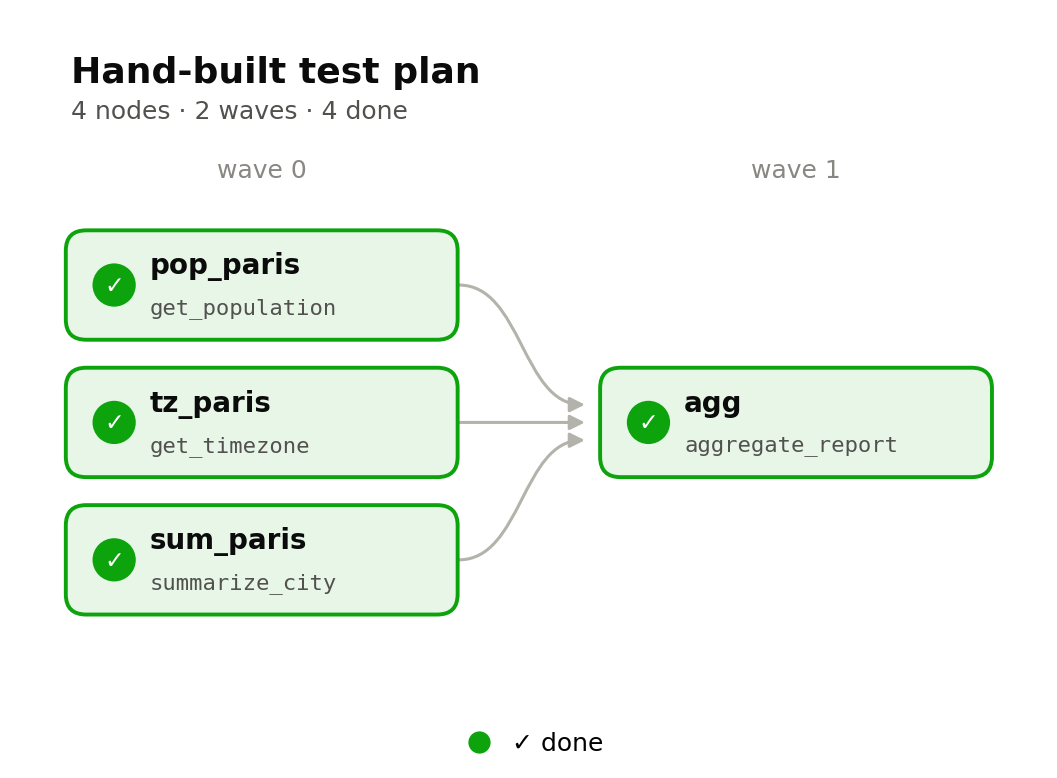

In [12]:
test_plan.plot("test_plan_dag.png", title="Hand-built test plan")
Image("test_plan_dag.png")

### Interpreting the parallel DAG demo

When the cell above finishes, you should see:

1. **`pop_paris`, `tz_paris`, `sum_paris`** all reach `status=done` — they had empty `deps` and ran concurrently (subject to `MAX_CONCURRENT`)
2. **`agg`** runs last — its `deps` list forced it to wait for all three fetches
3. **`events`** holds `(node_id, wall_seconds)` pairs — compare the fetch latencies; the aggregate step typically dominates when it calls the LLM

If you re-run with `BACKEND = "mock"`, latencies collapse and outputs become deterministic. With `anthropic`, `sum_paris` and `agg` vary — that's expected; structure (DAG order, validation, verification) is what the harness guarantees.


## 5. Multi-tier memory

In [13]:
def _bag(text: str) -> set[str]:
    return set(re.findall(r"\w+", text.lower()))


def _sim(a: str, b: str) -> float:
    ba, bb = _bag(a), _bag(b)
    if not ba or not bb:
        return 0.0
    return len(ba & bb) / len(ba | bb)   # Jaccard — fine for teaching


@dataclass
class Memory:
    content: str
    kind: str                           # "episodic" | "semantic"
    metadata: dict = field(default_factory=dict)
    embedding: Optional[Any] = None     # Store embedding if using real embeddings


class MemoryStore:
    """Similarity store with optional real embeddings support."""

    def __init__(self, use_embeddings: bool = USE_REAL_EMBEDDINGS) -> None:
        self._items: list[Memory] = []
        self._use_embeddings = use_embeddings
        self._model = None
        
        if self._use_embeddings:
            try:
                self._model = SentenceTransformer('all-MiniLM-L6-v2')
                print("MemoryStore: Using sentence-transformers embeddings (all-MiniLM-L6-v2)")
            except Exception as e:
                print(f"Failed to load embedding model: {e}")
                print("Falling back to Jaccard similarity")
                self._use_embeddings = False
        else:
            print("MemoryStore: Using Jaccard similarity")

    def add(self, content: str, kind: str, **meta) -> None:
        embedding = None
        if self._use_embeddings and self._model is not None:
            embedding = self._model.encode(content, convert_to_tensor=False)
        self._items.append(Memory(content=content, kind=kind, metadata=meta, embedding=embedding))

    def retrieve(self, query: str, k: int = 3, kind: str | None = None) -> list[Memory]:
        pool = self._items if kind is None else [m for m in self._items if m.kind == kind]
        
        if self._use_embeddings and self._model is not None:
            # Use cosine similarity with embeddings
            query_emb = self._model.encode(query, convert_to_tensor=False)
            scored = []
            for m in pool:
                if m.embedding is not None:
                    # Cosine similarity
                    sim = np.dot(query_emb, m.embedding) / (
                        np.linalg.norm(query_emb) * np.linalg.norm(m.embedding)
                    )
                    scored.append((m, float(sim)))
                else:
                    # Fallback to Jaccard if embedding missing
                    scored.append((m, _sim(query, m.content)))
        else:
            # Use Jaccard similarity
            scored = [(m, _sim(query, m.content)) for m in pool]
        
        scored.sort(key=lambda x: x[1], reverse=True)
        return [m for m, score in scored[:k] if score > 0]


@dataclass
class WorkingMemory:
    """Stays in context for the current task."""
    goal: str
    plan_summary: str = ""
    recent_results: list[str] = field(default_factory=list)

    def to_prompt(self) -> str:
        parts = [f"Goal: {self.goal}"]
        if self.plan_summary:
            parts.append(f"Plan: {self.plan_summary}")
        if self.recent_results:
            parts.append("Recent results:")
            for r in self.recent_results[-5:]:
                parts.append(f"  - {r}")
        return "\n".join(parts)


def build_context(working: WorkingMemory, store: MemoryStore,
                  budget_chars: int = 4000) -> str:
    """Assemble working memory + retrieved memories, respecting a char budget."""
    pieces: list[str] = [working.to_prompt()]
    used = len(pieces[0])

    # Episodic first (past similar tasks), then semantic (facts)
    for kind in ("episodic", "semantic"):
        for m in store.retrieve(working.goal, k=3, kind=kind):
            snippet = f"[{kind}] {m.content}"
            if used + len(snippet) + 1 > budget_chars:
                return "\n".join(pieces) + "\n(...truncated at budget...)"
            pieces.append(snippet)
            used += len(snippet) + 1

    return "\n".join(pieces)


# Seed the store with a past episode and a couple of semantic facts
store = MemoryStore()
store.add(
    "Previously built a 2-city comparison; forgot to include timezone. "
    "Reminder: always verify every requested attribute is present.",
    kind="episodic",
)
store.add("The Eiffel Tower is in Paris and is 330 meters tall.", kind="semantic")
store.add("Tokyo's Shibuya crossing is one of the busiest intersections in the world.", kind="semantic")

# Preview
working = WorkingMemory(goal="Compare Paris, Tokyo, and New York on population and timezone.")
print(build_context(working, store))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MemoryStore: Using sentence-transformers embeddings (all-MiniLM-L6-v2)
Goal: Compare Paris, Tokyo, and New York on population and timezone.
[episodic] Previously built a 2-city comparison; forgot to include timezone. Reminder: always verify every requested attribute is present.
[semantic] Tokyo's Shibuya crossing is one of the busiest intersections in the world.
[semantic] The Eiffel Tower is in Paris and is 330 meters tall.


## 6. Verification hierarchy

The **Worker** produces; the **Critic** evaluates. Keeping verification out of the generation loop:

- Prevents the generator from "grading its own homework"
- Lets you skip the critic under budget pressure (Section 10: `pressure() > 0.9`)
- Makes eval harnesses deterministic at the first tier

In [14]:
@dataclass
class Verdict:
    passed: bool
    tier: str                     # "deterministic" | "diff" | "llm_judge"
    reason: str = ""


def deterministic_check_report(report: str, required_cities: list[str]) -> Verdict:
    """The report must be non-empty and mention every required city."""
    if not report or not report.strip():
        return Verdict(False, "deterministic", "Empty report.")
    missing = [c for c in required_cities if c.lower() not in report.lower()]
    if missing:
        return Verdict(False, "deterministic", f"Missing cities: {missing}")
    return Verdict(True, "deterministic", "All required cities present.")


def llm_judge_report(report: str, goal: str, provider: LLMProvider) -> Verdict:
    """Ask the LLM to grade the report against the goal. Returns JSON {pass, reason}."""
    raw = provider.complete(
        system=(
            "You are a strict grader. Given a GOAL and a REPORT, decide whether "
            "the report satisfies the goal. Respond ONLY with JSON: "
            '{"pass": true|false, "reason": "..."}.'
        ),
        user=f"GOAL:\n{goal}\n\nREPORT:\n{report}",
        role="critic",
    )
    try:
        data = _safe_json_loads(raw)
        return Verdict(bool(data["pass"]), "llm_judge", data.get("reason", ""))
    except Exception as e:
        return Verdict(False, "llm_judge", f"Judge output malformed: {e}")


def verify_report(report: str, goal: str, required_cities: list[str],
                  provider: LLMProvider) -> Verdict:
    det = deterministic_check_report(report, required_cities)
    if not det.passed:
        return det                # Cheap tier caught it — don't bother the LLM
    # Deterministic passed → escalate to LLM judge for subjective quality
    return llm_judge_report(report, goal, provider)


# Quick check: a report missing a city should fail at the deterministic tier
v = verify_report(
    "Paris has 2.1M people.",
    goal="Compare Paris, Tokyo, and New York.",
    required_cities=["Paris", "Tokyo", "New York"],
    provider=llm,
)
print(v)

Verdict(passed=False, tier='deterministic', reason="Missing cities: ['Tokyo', 'New York']")


## 7. Multi-agent roles

`LLMProvider.complete(..., role="planner")` lets one backend apply role-specific behavior — e.g. `AnthropicProvider` appends "respond with ONLY JSON" for structured roles, and `MockProvider` returns canned DAGs. Same interface, different contracts per role.


### Planner and Critic agents

**`PlannerAgent.plan()`** injects the full tool schema JSON into the system prompt via `<<TOOLS_JSON>>` substitution. The planner sees exactly what the worker can call — no hallucinated tool names.

**`PlannerAgent.replan()`** adds failure context: which node failed, with what args, and the error string. This is the minimum viable context for informed recovery.

**`CriticAgent`** is a thin wrapper over `verify_report()` — keeping the critic as its own class lets the orchestrator trace critic steps separately and skip them under budget pressure.


In [15]:
PLANNER_SYSTEM = """You are a Planner agent. Given a GOAL, produce a dependency graph
of tool calls that will satisfy it.

Output ONLY JSON in this shape (no prose, no markdown):
{"nodes": [{"id": "...", "tool": "...", "args": {...}, "deps": [...]}, ...]}

Nodes may run in parallel if their `deps` are empty or already satisfied.
The final aggregate_report node must depend on all upstream fetch/summary nodes.
Prefer id "aggregate" for that capstone node (any unique id is acceptable).
Available tools (name and schema):
<<TOOLS_JSON>>
"""


class PlannerAgent:
    def __init__(self, provider: LLMProvider, tools: dict[str, TypedTool]):
        self._provider = provider
        self._tools = tools

    def plan(self, goal: str) -> PlanDAG:
        tools_json = json.dumps([t.schema() for t in self._tools.values()], indent=2)
        system = PLANNER_SYSTEM.replace("<<TOOLS_JSON>>", tools_json)
        raw = self._provider.complete(system=system, user=f"GOAL: {goal}",
                                       role="planner")
        return PlanDAG.from_json(_safe_json_loads(raw))

    def replan(self, goal: str, failed_dag: PlanDAG) -> PlanDAG:
        """Re-plan after failures, providing context about what failed."""
        tools_json = json.dumps([t.schema() for t in self._tools.values()], indent=2)
        system = PLANNER_SYSTEM.replace("<<TOOLS_JSON>>", tools_json)
        
        # Collect failure information
        failures = []
        for node in failed_dag.nodes.values():
            if node.status == NodeStatus.FAILED:
                failures.append(f"Node {node.id} (tool={node.tool}, args={node.args}) failed: {node.error}")
        
        failure_context = "\n".join(failures)
        user_prompt = (
            f"GOAL: {goal}\n\n"
            f"Previous plan failed with these errors:\n{failure_context}\n\n"
            f"Please provide an amended plan that avoids these failures."
        )
        
        raw = self._provider.complete(system=system, user=user_prompt, role="replanner")
        return PlanDAG.from_json(_safe_json_loads(raw))


class CriticAgent:
    def __init__(self, provider: LLMProvider):
        self._provider = provider

    def judge(self, report: str, goal: str, required_cities: list[str]) -> Verdict:
        return verify_report(report, goal, required_cities, self._provider)

### Planner / Critic code structure

The cell defines:

- **`PLANNER_SYSTEM`** — template with `<<TOOLS_JSON>>` placeholder. At runtime, `PlannerAgent` substitutes the live tool registry so the planner never hallucinates tool names absent from `TOOLS`.
- **`PlannerAgent.plan()`** — one LLM call → validated `PlanDAG`. Validation happens in `PlanDAG.from_json()`, not in the agent — separation of concerns.
- **`PlannerAgent.replan()`** — same contract, but the user message includes structured failure context (demonstrated in notebook 04).
- **`CriticAgent`** — thin wrapper; keeps critic logic swappable without touching the orchestrator.

The Worker is defined in the next cells — execution stays deliberately dumb so planning and judgment remain inspectable.


### The Worker agent (initial version)

At this point the `WorkerAgent` is intentionally thin — it delegates to `execute_dag`. The Worker **does not replan** and **does not judge**; it only executes what the DAG specifies.

In notebook 04 we split the Worker into **FetcherAgent** (cheap lookups) and **WriterAgent** (LLM-backed composition). That split reflects a common production pattern: different worker pools with different concurrency limits, retry policies, and monitoring — e.g. a browser agent capped at 2 tabs vs a code agent capped at 10 parallel file reads.


In [16]:
class WorkerAgent:
    """Runs the DAG produced by the Planner."""

    def __init__(self, tools: dict[str, TypedTool]):
        self._tools = tools

    async def execute(self, dag: PlanDAG,
                      on_step: Callable[[PlanNode, float], None] | None = None) -> None:
        await execute_dag(dag, self._tools, on_step=on_step)


## 8. Budgeting and recovery strategies

### Budget and error-handling implementation

The next cell defines the operational guardrails:

- **`BudgetMulti`** — tracks tokens, tool calls, wall time, and estimated USD; exposes `pressure()` for degradation decisions
- **`ErrorClass`** — buckets failures so recovery is intentional (retry vs replan vs abort)
- **`classify_error()`** — heuristic string matcher; production would use structured API error codes
- **`retry_with_backoff()`** — exponential backoff with jitter for transient failures only

These utilities are imported by the orchestrator — they are not agent roles themselves.


In [17]:
@dataclass
class BudgetMulti:
    max_tokens: int = 50_000
    max_tool_calls: int = 30
    max_wall_seconds: float = 60.0
    max_cost_usd: float = 0.50

    tokens_used: int = 0
    tool_calls_used: int = 0
    cost_usd: float = 0.0
    started_at: float = field(default_factory=time.time)

    def elapsed(self) -> float:
        return time.time() - self.started_at

    def has_room(self) -> bool:
        return (
            self.tokens_used < self.max_tokens
            and self.tool_calls_used < self.max_tool_calls
            and self.elapsed() < self.max_wall_seconds
            and self.cost_usd < self.max_cost_usd
        )

    def pressure(self) -> float:
        return max(
            self.tokens_used / self.max_tokens,
            self.tool_calls_used / self.max_tool_calls,
            self.elapsed() / self.max_wall_seconds,
            self.cost_usd / self.max_cost_usd,
        )

    def charge(self, *, tokens: int = 0, cost: float = 0.0,
               tool_calls: int = 0) -> None:
        self.tokens_used += tokens
        self.cost_usd += cost
        self.tool_calls_used += tool_calls


class ErrorClass(str, Enum):
    TRANSIENT = "transient"       # rate limit, timeout → backoff + retry
    TOOL_MISUSE = "tool_misuse"   # bad args → let LLM self-correct
    MISSING_INFO = "missing_info" # 404, not found → re-plan
    FATAL = "fatal"               # security violation, policy → halt


def classify_error(err: str) -> ErrorClass:
    e = err.lower()
    if any(s in e for s in ("timeout", "rate limit", "503", "502", "connection")):
        return ErrorClass.TRANSIENT
    if "validationerror" in e or "missing" in e and "arg" in e:
        return ErrorClass.TOOL_MISUSE
    if "keyerror" in e or "not found" in e or "unknown" in e:
        return ErrorClass.MISSING_INFO
    return ErrorClass.FATAL


async def retry_with_backoff(fn: Callable[[], Any], *,
                              max_retries: int = 3) -> Any:
    """Retry a callable on TRANSIENT errors with exponential backoff + jitter."""
    for attempt in range(max_retries + 1):
        try:
            return await fn() if asyncio.iscoroutinefunction(fn) else fn()
        except Exception as exc:
            err_cls = classify_error(str(exc))
            if err_cls != ErrorClass.TRANSIENT or attempt >= max_retries:
                raise
            wait = min(2 ** attempt + random.uniform(0, 1), 10)
            await asyncio.sleep(wait)
    raise RuntimeError("unreachable")


## 9. Structured observability and tracing

### `TraceEvent` design

Each event captures:

- **Identity** — `step_id`, `parent_id` (links worker steps to the plan that spawned them)
- **Semantics** — `role` (planner/worker/critic), `action` dict, truncated `result`
- **Economics** — `latency_ms`, `tokens`, `cost_usd`, `budget_pressure`
- **Quality** — optional `verdict` from the critic

This schema is intentionally flat (list of dicts) so you can dump to JSON, ship to OpenTelemetry, or plot in matplotlib without a complex object graph.

### What tracing enables downstream

- **Debugging** — "the aggregator waited 8s because summarize_city nodes were slow"
- **Optimization** — identify which tool dominates latency
- **Eval regression** — compare trace summaries across harness versions
- **Billing** — attribute cost to planner vs worker vs critic


In [18]:
@dataclass
class TraceEvent:
    step_id: str
    parent_id: Optional[str]
    timestamp: float
    role: str                         # "planner" | "worker" | "critic"
    action: dict
    result: Any
    latency_ms: int
    tokens: int
    cost_usd: float
    budget_pressure: float
    verdict: Optional[dict] = None    # {passed, tier, reason}

    def to_json(self) -> dict:
        return {
            "step_id": self.step_id,
            "parent_id": self.parent_id,
            "timestamp": self.timestamp,
            "role": self.role,
            "action": self.action,
            "result": _truncate(self.result, 200),
            "latency_ms": self.latency_ms,
            "tokens": self.tokens,
            "cost_usd": round(self.cost_usd, 6),
            "budget_pressure": round(self.budget_pressure, 3),
            "verdict": self.verdict,
        }


def _truncate(x: Any, n: int) -> Any:
    s = str(x)
    return s if len(s) <= n else s[:n] + f"...(+{len(s) - n} chars)"


class Tracer:
    def __init__(self) -> None:
        self.events: list[TraceEvent] = []

    def record(self, **kwargs) -> TraceEvent:
        ev = TraceEvent(**kwargs)
        self.events.append(ev)
        return ev

    def dump(self) -> list[dict]:
        return [e.to_json() for e in self.events]

    def new_step_id(self, prefix: str = "s") -> str:
        return f"{prefix}-{len(self.events):04d}"


## 10. Putting it all together

### Orchestrator implementation

The next cell defines the **`Orchestrator`** class — the composition root that wires every primitive from Sections 1–9.

**Constructor dependencies:**
- `provider` — LLM backend for planner/critic/LLM-backed tools
- `tools` — registry the worker dispatches through
- `memory` — episodic store updated after each run
- `max_replans` — cap on plan-and-execute cycles after `MISSING_INFO` failures

**Internal agents:** `PlannerAgent`, `WorkerAgent`, `CriticAgent` — created once, reused per run.

**Key design choice:** The orchestrator *records* and *charges budget* but never implements domain logic (no city parsing, no report formatting). That keeps it stable as tools and verifiers evolve.


In [19]:
# Rough cost-per-token estimate (Anthropic Sonnet-class pricing, illustrative)
COST_PER_1K_TOKENS = 0.003


@dataclass
class RunResult:
    goal: str
    report: Optional[str]
    verdict: Optional[Verdict]
    dag: PlanDAG
    tracer: Tracer
    budget: BudgetMulti
    status: str                      # "ok" | "failed_verify" | "failed_execute" | "budget" | "replanned"
    replan_count: int = 0            # Track how many times we replanned


class Orchestrator:
    def __init__(self, provider: LLMProvider, tools: dict[str, TypedTool],
                 memory: MemoryStore, max_replans: int = 2):
        self._provider = provider
        self._tools = tools
        self._memory = memory
        self._max_replans = max_replans
        self.planner = PlannerAgent(provider, tools)
        self.worker = WorkerAgent(tools)
        self.critic = CriticAgent(provider)

    async def run(self, goal: str, required_cities: list[str],
                   budget: Optional[BudgetMulti] = None) -> RunResult:
        budget = budget or BudgetMulti()
        tracer = Tracer()
        replan_count = 0

        # --- 1. Plan (with re-planning loop) ---
        dag = None
        for attempt in range(self._max_replans + 1):
            t0 = time.time()
            
            if attempt == 0:
                # Initial plan
                dag = self.planner.plan(goal)
                plan_type = "initial_plan"
            else:
                # Re-plan after failure
                dag = self.planner.replan(goal, dag)
                plan_type = "replan"
                replan_count += 1
            
            plan_latency = int((time.time() - t0) * 1000)
            est_tokens = (len(goal) + sum(len(n.tool) + len(json.dumps(n.args)) for n in dag.nodes.values())) // 4
            budget.charge(tokens=est_tokens,
                          cost=est_tokens * COST_PER_1K_TOKENS / 1000)
            tracer.record(
                step_id=tracer.new_step_id("plan"), parent_id=None,
                timestamp=time.time(), role="planner",
                action={"type": plan_type, "goal": goal, "attempt": attempt},
                result={"n_nodes": len(dag.nodes)},
                latency_ms=plan_latency, tokens=est_tokens,
                cost_usd=est_tokens * COST_PER_1K_TOKENS / 1000,
                budget_pressure=budget.pressure(),
            )

            # --- 2. Execute with per-step tracing ---
            def on_step(node: PlanNode, wall_s: float) -> None:
                tool = self._tools[node.tool]
                toks = int(max(20, tool.cost_hint * 200))
                budget.charge(tokens=toks,
                              cost=toks * COST_PER_1K_TOKENS / 1000,
                              tool_calls=1)
                tracer.record(
                    step_id=tracer.new_step_id("w"), parent_id=f"plan-{len([e for e in tracer.events if e.role == 'planner']) - 1:04d}",
                    timestamp=time.time(), role="worker",
                    action={"type": "tool_call", "tool": node.tool, "args": node.args},
                    result=node.result if node.status == NodeStatus.DONE else node.error,
                    latency_ms=int(wall_s * 1000),
                    tokens=toks, cost_usd=toks * COST_PER_1K_TOKENS / 1000,
                    budget_pressure=budget.pressure(),
                )

            try:
                await self.worker.execute(dag, on_step=on_step)
            except Exception as exc:
                if attempt < self._max_replans and budget.has_room():
                    continue  # Try re-planning
                return RunResult(goal=goal, report=None, verdict=None, dag=dag,
                                 tracer=tracer, budget=budget,
                                 status=f"failed_execute:{exc}", replan_count=replan_count)

            # Check if we need to re-plan
            if dag.any_failed():
                if attempt < self._max_replans and budget.has_room():
                    # Classify errors to decide if re-planning makes sense
                    should_replan = False
                    for node in dag.nodes.values():
                        if node.status == NodeStatus.FAILED:
                            err_class = classify_error(node.error or "")
                            if err_class == ErrorClass.MISSING_INFO:
                                should_replan = True
                                break
                    
                    if should_replan:
                        continue  # Re-plan
                
                # Can't or shouldn't re-plan
                return RunResult(goal=goal, report=None, verdict=None, dag=dag,
                                 tracer=tracer, budget=budget, status="failed_execute",
                                 replan_count=replan_count)
            
            # Success - break out of re-planning loop
            break

        agg_node = dag.aggregate_node()
        if agg_node is None or agg_node.status != NodeStatus.DONE:
            return RunResult(goal=goal, report=None, verdict=None, dag=dag,
                             tracer=tracer, budget=budget, status="failed_execute",
                             replan_count=replan_count)

        report = agg_node.result

        # Pressure-aware degradation: skip LLM judge if budget is tight
        if budget.pressure() > 0.9:
            verdict = deterministic_check_report(report, required_cities)
        else:
            verdict = self.critic.judge(report, goal, required_cities)

        tracer.record(
            step_id=tracer.new_step_id("c"), parent_id=f"plan-{len([e for e in tracer.events if e.role == 'planner']) - 1:04d}",
            timestamp=time.time(), role="critic",
            action={"type": "verify"},
            result={"passed": verdict.passed, "tier": verdict.tier},
            latency_ms=0, tokens=100,
            cost_usd=100 * COST_PER_1K_TOKENS / 1000,
            budget_pressure=budget.pressure(),
            verdict={"passed": verdict.passed, "tier": verdict.tier,
                     "reason": verdict.reason},
        )

        # Stash the outcome in episodic memory for future runs
        self._memory.add(
            f"Task: {goal[:120]} → outcome: "
            f"{'pass' if verdict.passed else 'fail'} ({verdict.reason})",
            kind="episodic",
        )

        status = "ok" if verdict.passed else "failed_verify"
        if replan_count > 0:
            status = f"{status}_replanned_{replan_count}x"
        if not budget.has_room():
            status = "budget"
        return RunResult(goal=goal, report=report, verdict=verdict, dag=dag,
                         tracer=tracer, budget=budget, status=status,
                         replan_count=replan_count)

### Running the full pipeline

The cell below runs the orchestrator on a **three-city comparison** — the canonical demo task.

**What to watch for:**

1. **Planner** — one LLM call producing ~10 DAG nodes
2. **Worker** — up to 9 parallel fetches (3 cities × 3 attributes), then 1 aggregate
3. **Budget** — `summarize_city` and `aggregate_report` dominate token cost
4. **Critic** — deterministic check first; LLM judge only if structure passes
5. **Memory** — outcome stored as episodic memory for future runs

If you're using `AnthropicProvider`, planner output may differ slightly from `MockProvider` — that's expected. The harness constraints (schema validation, DAG structure, verification) are what keep behavior bounded.


In [20]:
orch = Orchestrator(provider=llm, tools=TOOLS, memory=store)

GOAL = (
    "Build a comparison report of Paris, Tokyo, and New York covering "
    "population, timezone, and a narrative summary for each."
)
REQUIRED = ["paris", "tokyo", "new york"]

result = asyncio.run(orch.run(GOAL, REQUIRED))

print(f"Status:        {result.status}")
print(f"Verdict:       passed={result.verdict.passed if result.verdict else 'n/a'}  "
      f"tier={result.verdict.tier if result.verdict else 'n/a'}")
print(f"Tokens used:   {result.budget.tokens_used}")
print(f"Tool calls:    {result.budget.tool_calls_used}")
print(f"Cost (est):    ${result.budget.cost_usd:.4f}")
print(f"Budget pressure final: {result.budget.pressure():.2f}")
print()
print("--- REPORT ---")
print(result.report)


Status:        failed_verify
Verdict:       passed=False  tier=llm_judge
Tokens used:   1235
Tool calls:    10
Cost (est):    $0.0037
Budget pressure final: 0.33

--- REPORT ---
# Global Cities Comparison Report

## Overview
This report provides a comparative analysis of three major global cities: Paris, Tokyo, and New York.

## Population Analysis

| City | Population | Rank |
|------|-----------|------|
| Tokyo | 13,960,000 | 1st |
| New York | 8,335,000 | 2nd |
| Paris | 2,100,000 | 3rd |

Tokyo is the most populous city among the three, with nearly 14 million residents. New York follows with approximately 8.3 million, while Paris has the smallest population at 2.1 million.

## Geographic Distribution

### By Country
- **Japan**: Tokyo (13,960,000)
- **USA**: New York (8,335,000)
- **France**: Paris (2,100,000)

## Time Zone Information

| City | Timezone | UTC Offset |
|------|----------|------------|
| Paris | CET | UTC+1 |
| New York | EST | UTC-5 |
| Tokyo | JST | UTC+9 |

## Ke

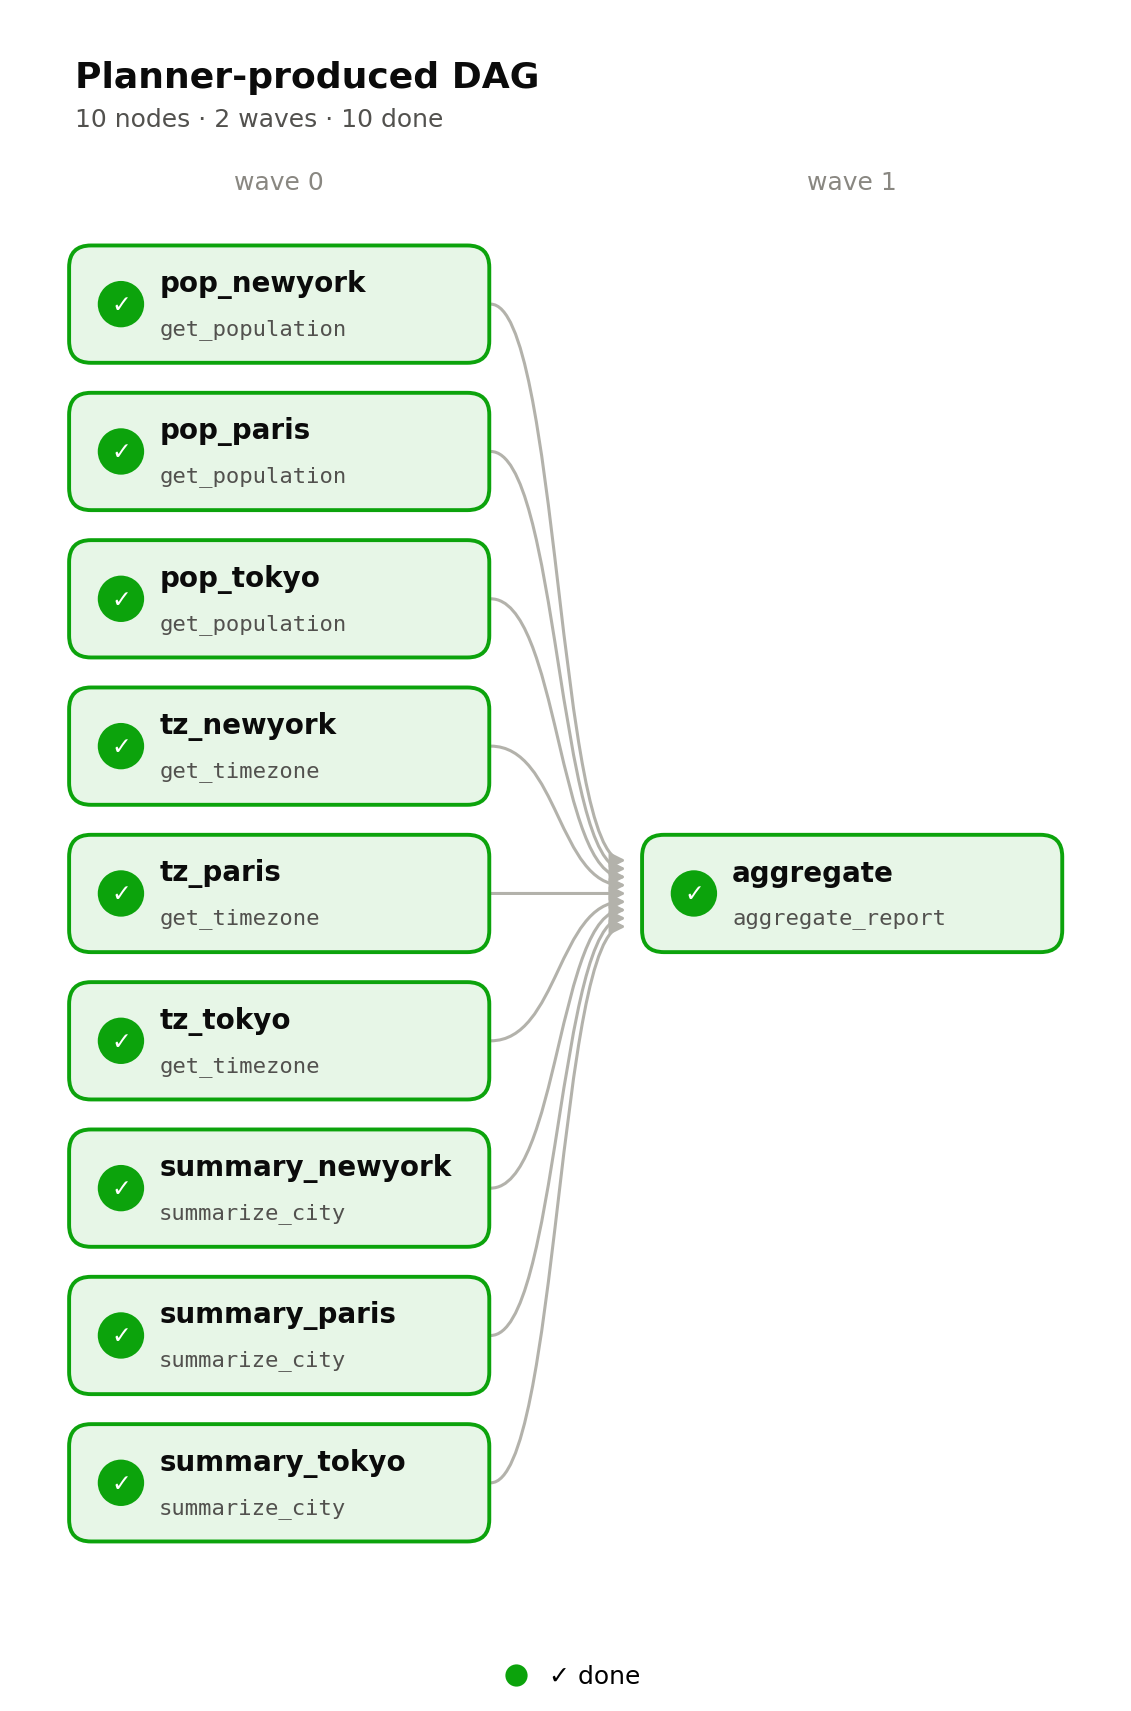

In [21]:
# Visualize the planner-produced DAG from the orchestrated run
result.dag.plot("orchestrator_dag.png", title="Planner-produced DAG")

Image("orchestrator_dag.png")

In [22]:
events = result.tracer.dump()
print(json.dumps(events[:3], indent=2))
print(f"\n... and {len(events) - 3} more events")


[
  {
    "step_id": "plan-0000",
    "parent_id": null,
    "timestamp": 1785499288.986136,
    "role": "planner",
    "action": {
      "type": "initial_plan",
      "goal": "Build a comparison report of Paris, Tokyo, and New York covering population, timezone, and a narrative summary for each.",
      "attempt": 0
    },
    "result": "{'n_nodes': 10}",
    "latency_ms": 2269,
    "tokens": 115,
    "cost_usd": 0.000345,
    "budget_pressure": 0.038,
    "verdict": null
  },
  {
    "step_id": "w-0001",
    "parent_id": "plan-0000",
    "timestamp": 1785499288.98671,
    "role": "worker",
    "action": {
      "type": "tool_call",
      "tool": "get_timezone",
      "args": {
        "city": "Paris"
      }
    },
    "result": "CET",
    "latency_ms": 0,
    "tokens": 20,
    "cost_usd": 6e-05,
    "budget_pressure": 0.038,
    "verdict": null
  },
  {
    "step_id": "w-0002",
    "parent_id": "plan-0000",
    "timestamp": 1785499288.986913,
    "role": "worker",
    "action": {
  

### Reading the trace plots

Three views of the same `TraceEvent` list:

1. **Latency by step** — tall bars on `summarize_*` and `aggregate` nodes mean LLM calls dominate wall time; flat bars on lookups mean parallelism helps
2. **Budget pressure over time** — monotonic rise is normal; a sharp jump at the aggregator reflects token-heavy synthesis. If pressure exceeds 0.9 before the critic, the orchestrator skips LLM judging
3. **Tokens by role** — shows whether planning or execution consumed the budget. City comparison tasks usually skew toward **worker** (many summarize calls)

These plots are stand-ins for dashboard panels — the underlying JSON is the durable artifact.


In [23]:
def get_strings(events):
    strings = []
    for event in events:
        action = event.get("action", {})
        if action.get("type") == "tool_call":
            # Create a string like toolname(arg1=val1, arg2=val2)
            tool = action.get("tool", "unknown_tool")
            args = action.get("args", {})
            # Ensure all values are string representations
            args_list = [f"{repr(v)}" for k, v in args.items()]
            func_str = f"{tool}({', '.join(args_list)})"
            strings.append(func_str)
        elif action.get("type") == "verify":
            strings.append("verify")
        elif action.get("type") == "initial_plan":
            strings.append("initial_plan")
        elif action.get("type") == "replan":
            strings.append("replan")
    return strings

## Plot 1: per-step latency, colored by role

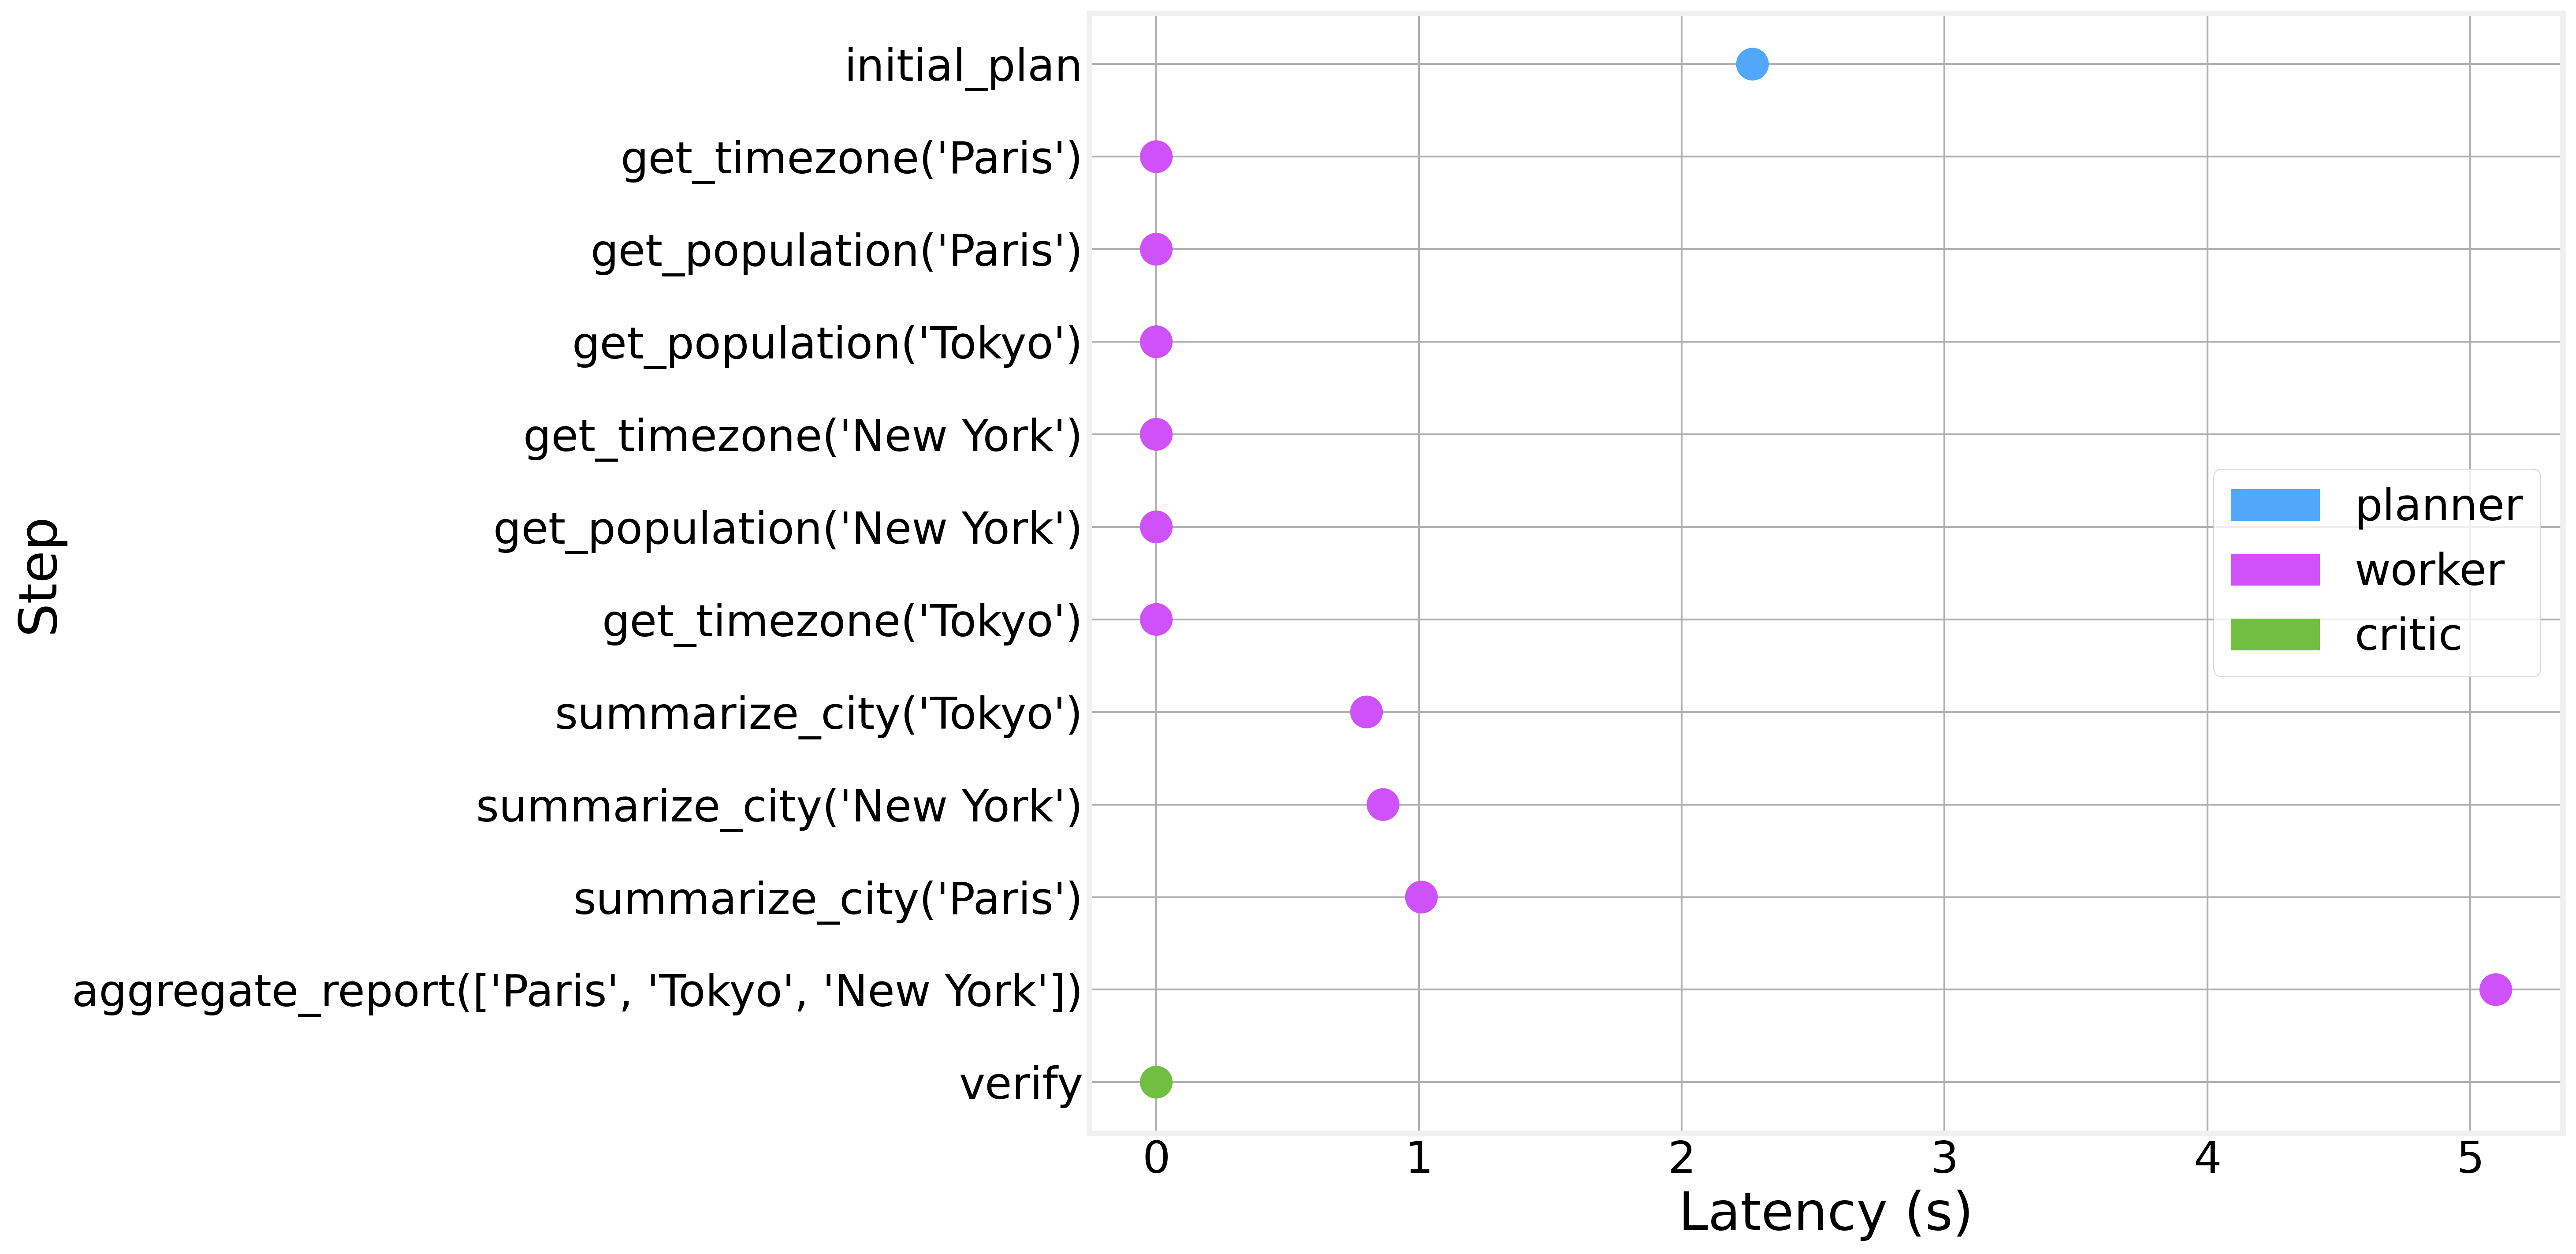

In [24]:
roles = [e["role"] for e in events]
latencies = np.array([e["latency_ms"] for e in events])

role_colors = {"planner": colors[0], "worker": colors[1], "critic": colors[2]}
bar_colors = [role_colors[e['role']] for e in events]
bar_strings = get_strings(events)

fig, ax = plt.subplots(figsize=(20, 10))
ax.scatter(latencies/1000, range(len(events)), color=bar_colors, s=300)
ax.set_ylabel("Step")
ax.set_xlabel("Latency (s)")
ax.set_yticks(range(len(events)))
ax.set_yticklabels(bar_strings)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in role_colors.values()]
ax.legend(handles, role_colors.keys(), loc="center right")
ax.invert_yaxis()
plt.tight_layout()

## Plot 2: cumulative budget pressure

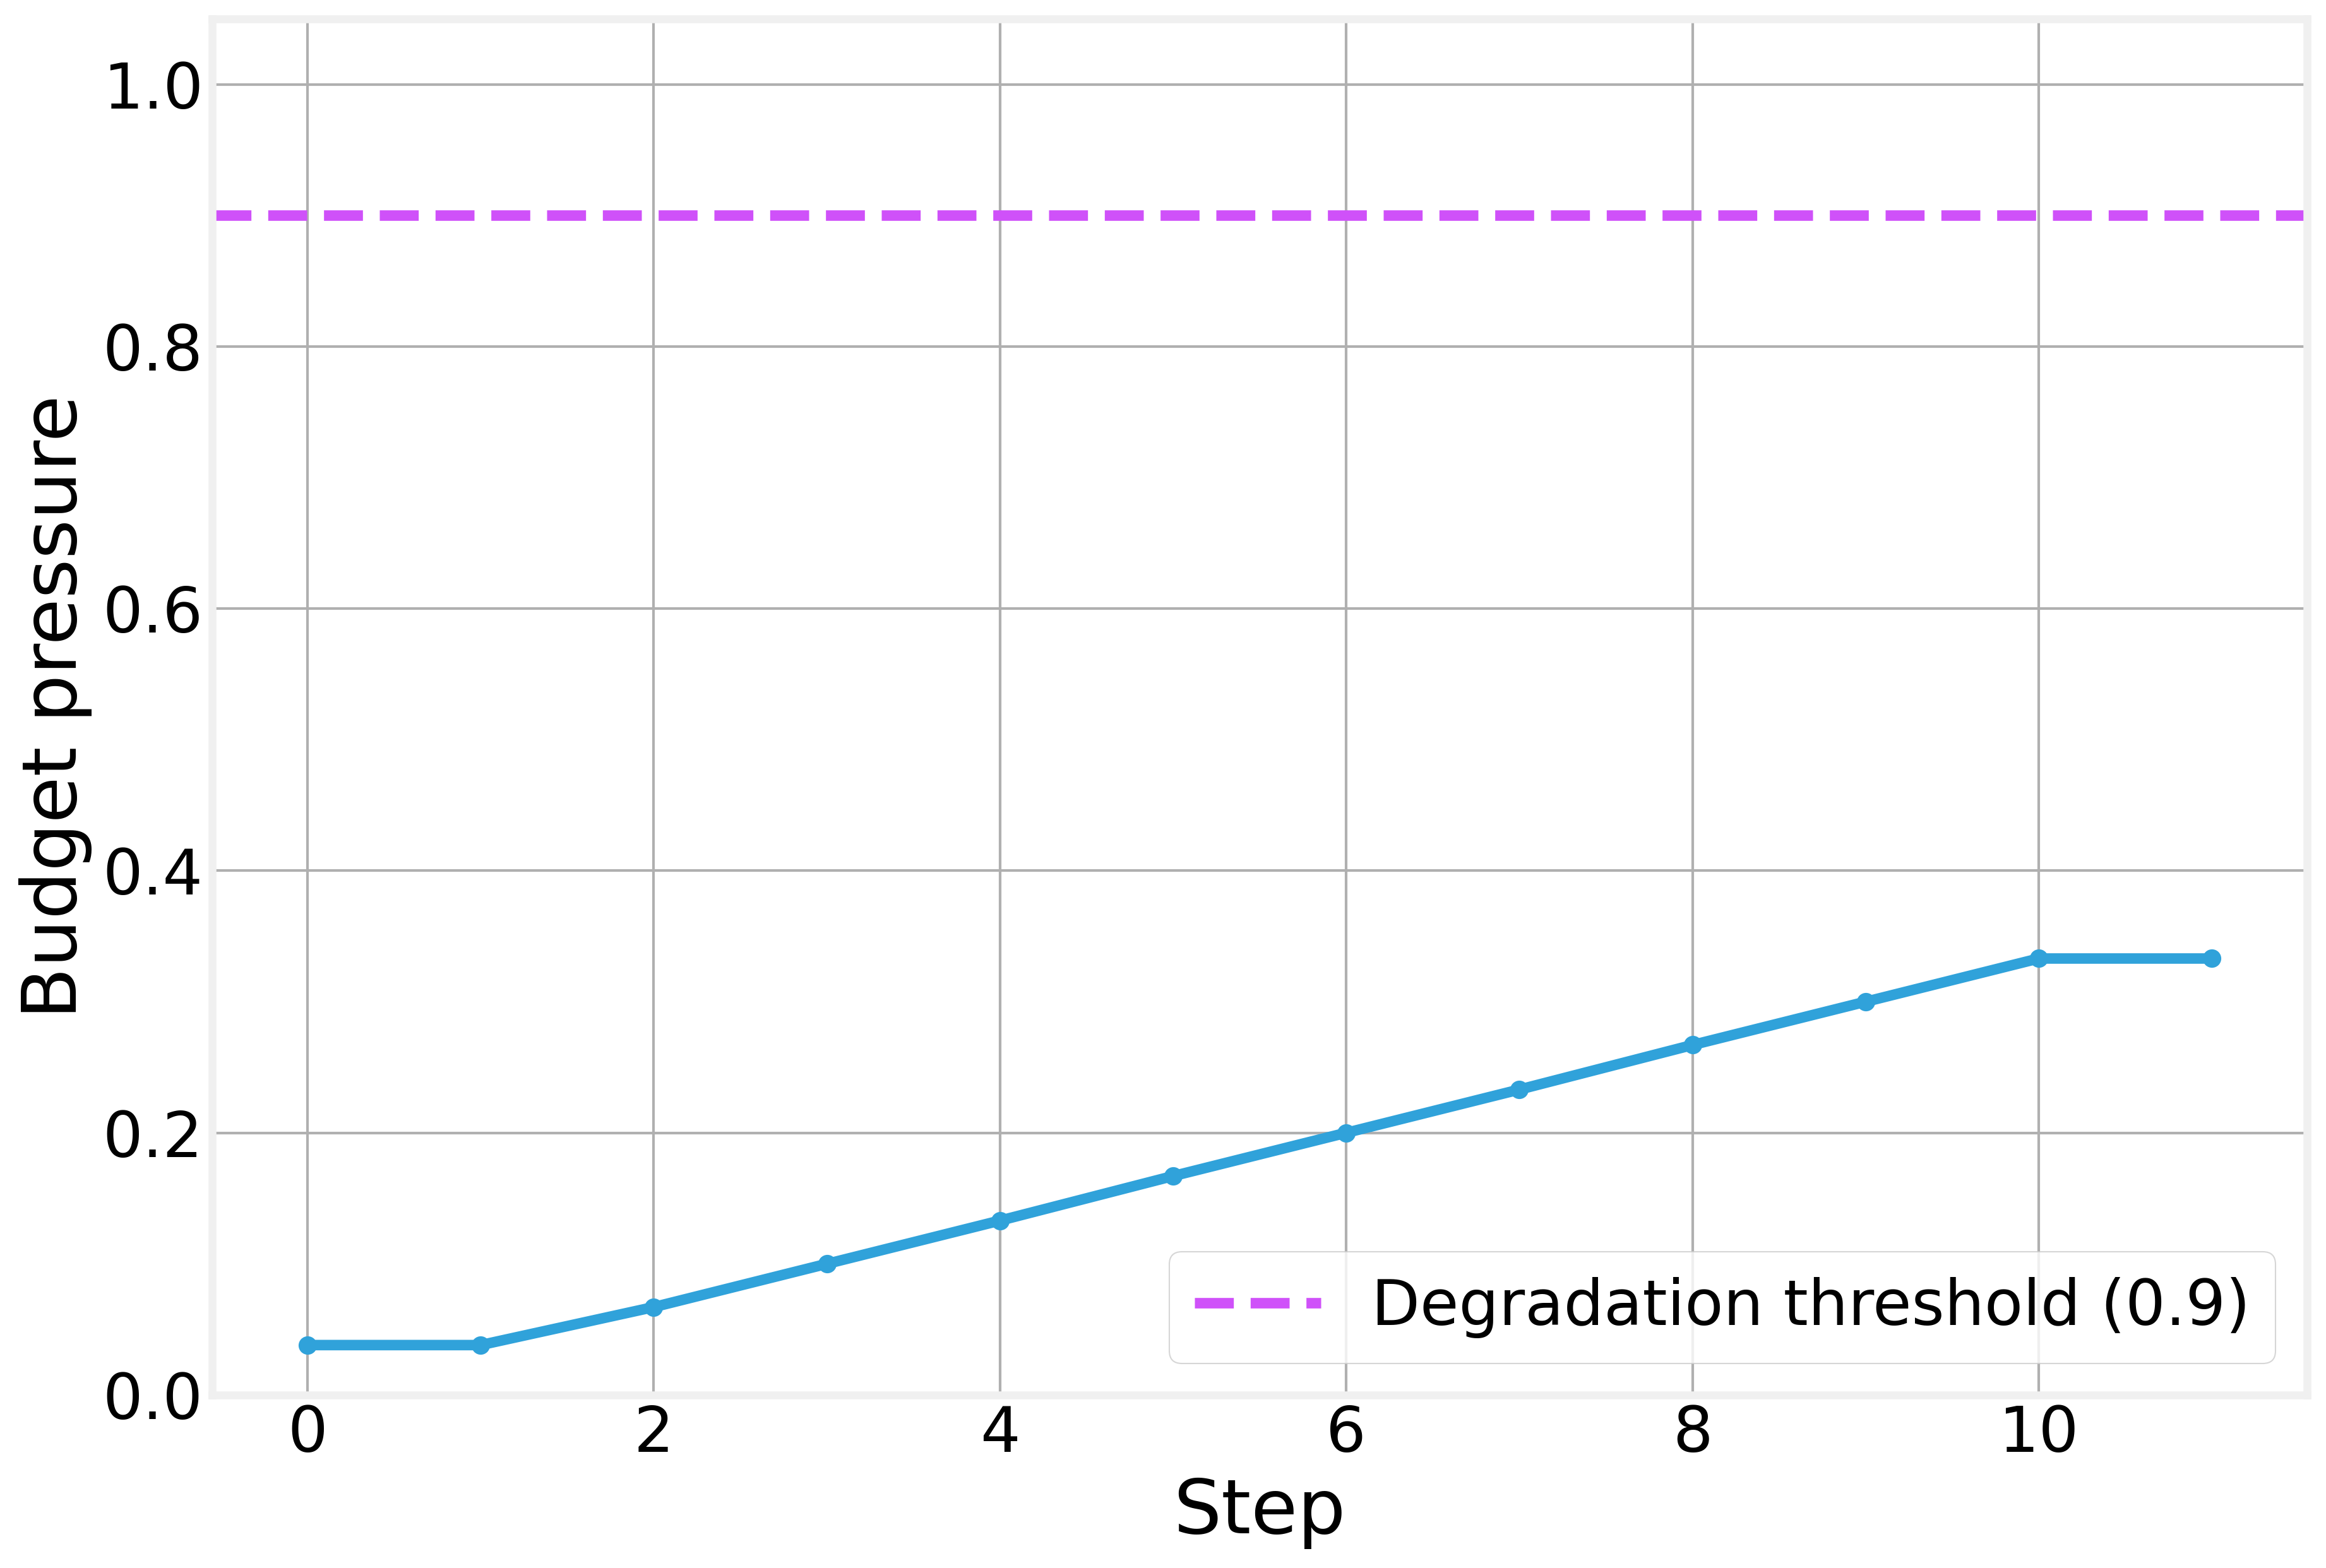

In [25]:
pressures = [e["budget_pressure"] for e in events]
fig, ax = plt.subplots()
ax.plot(range(len(events)), pressures, marker="o", color="#30a2da")
ax.axhline(0.9, linestyle="--", color=colors[1],
           label="Degradation threshold (0.9)")
ax.set_xlabel("Step")
ax.set_ylabel("Budget pressure")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.tight_layout()

## Plot 3: tokens by role

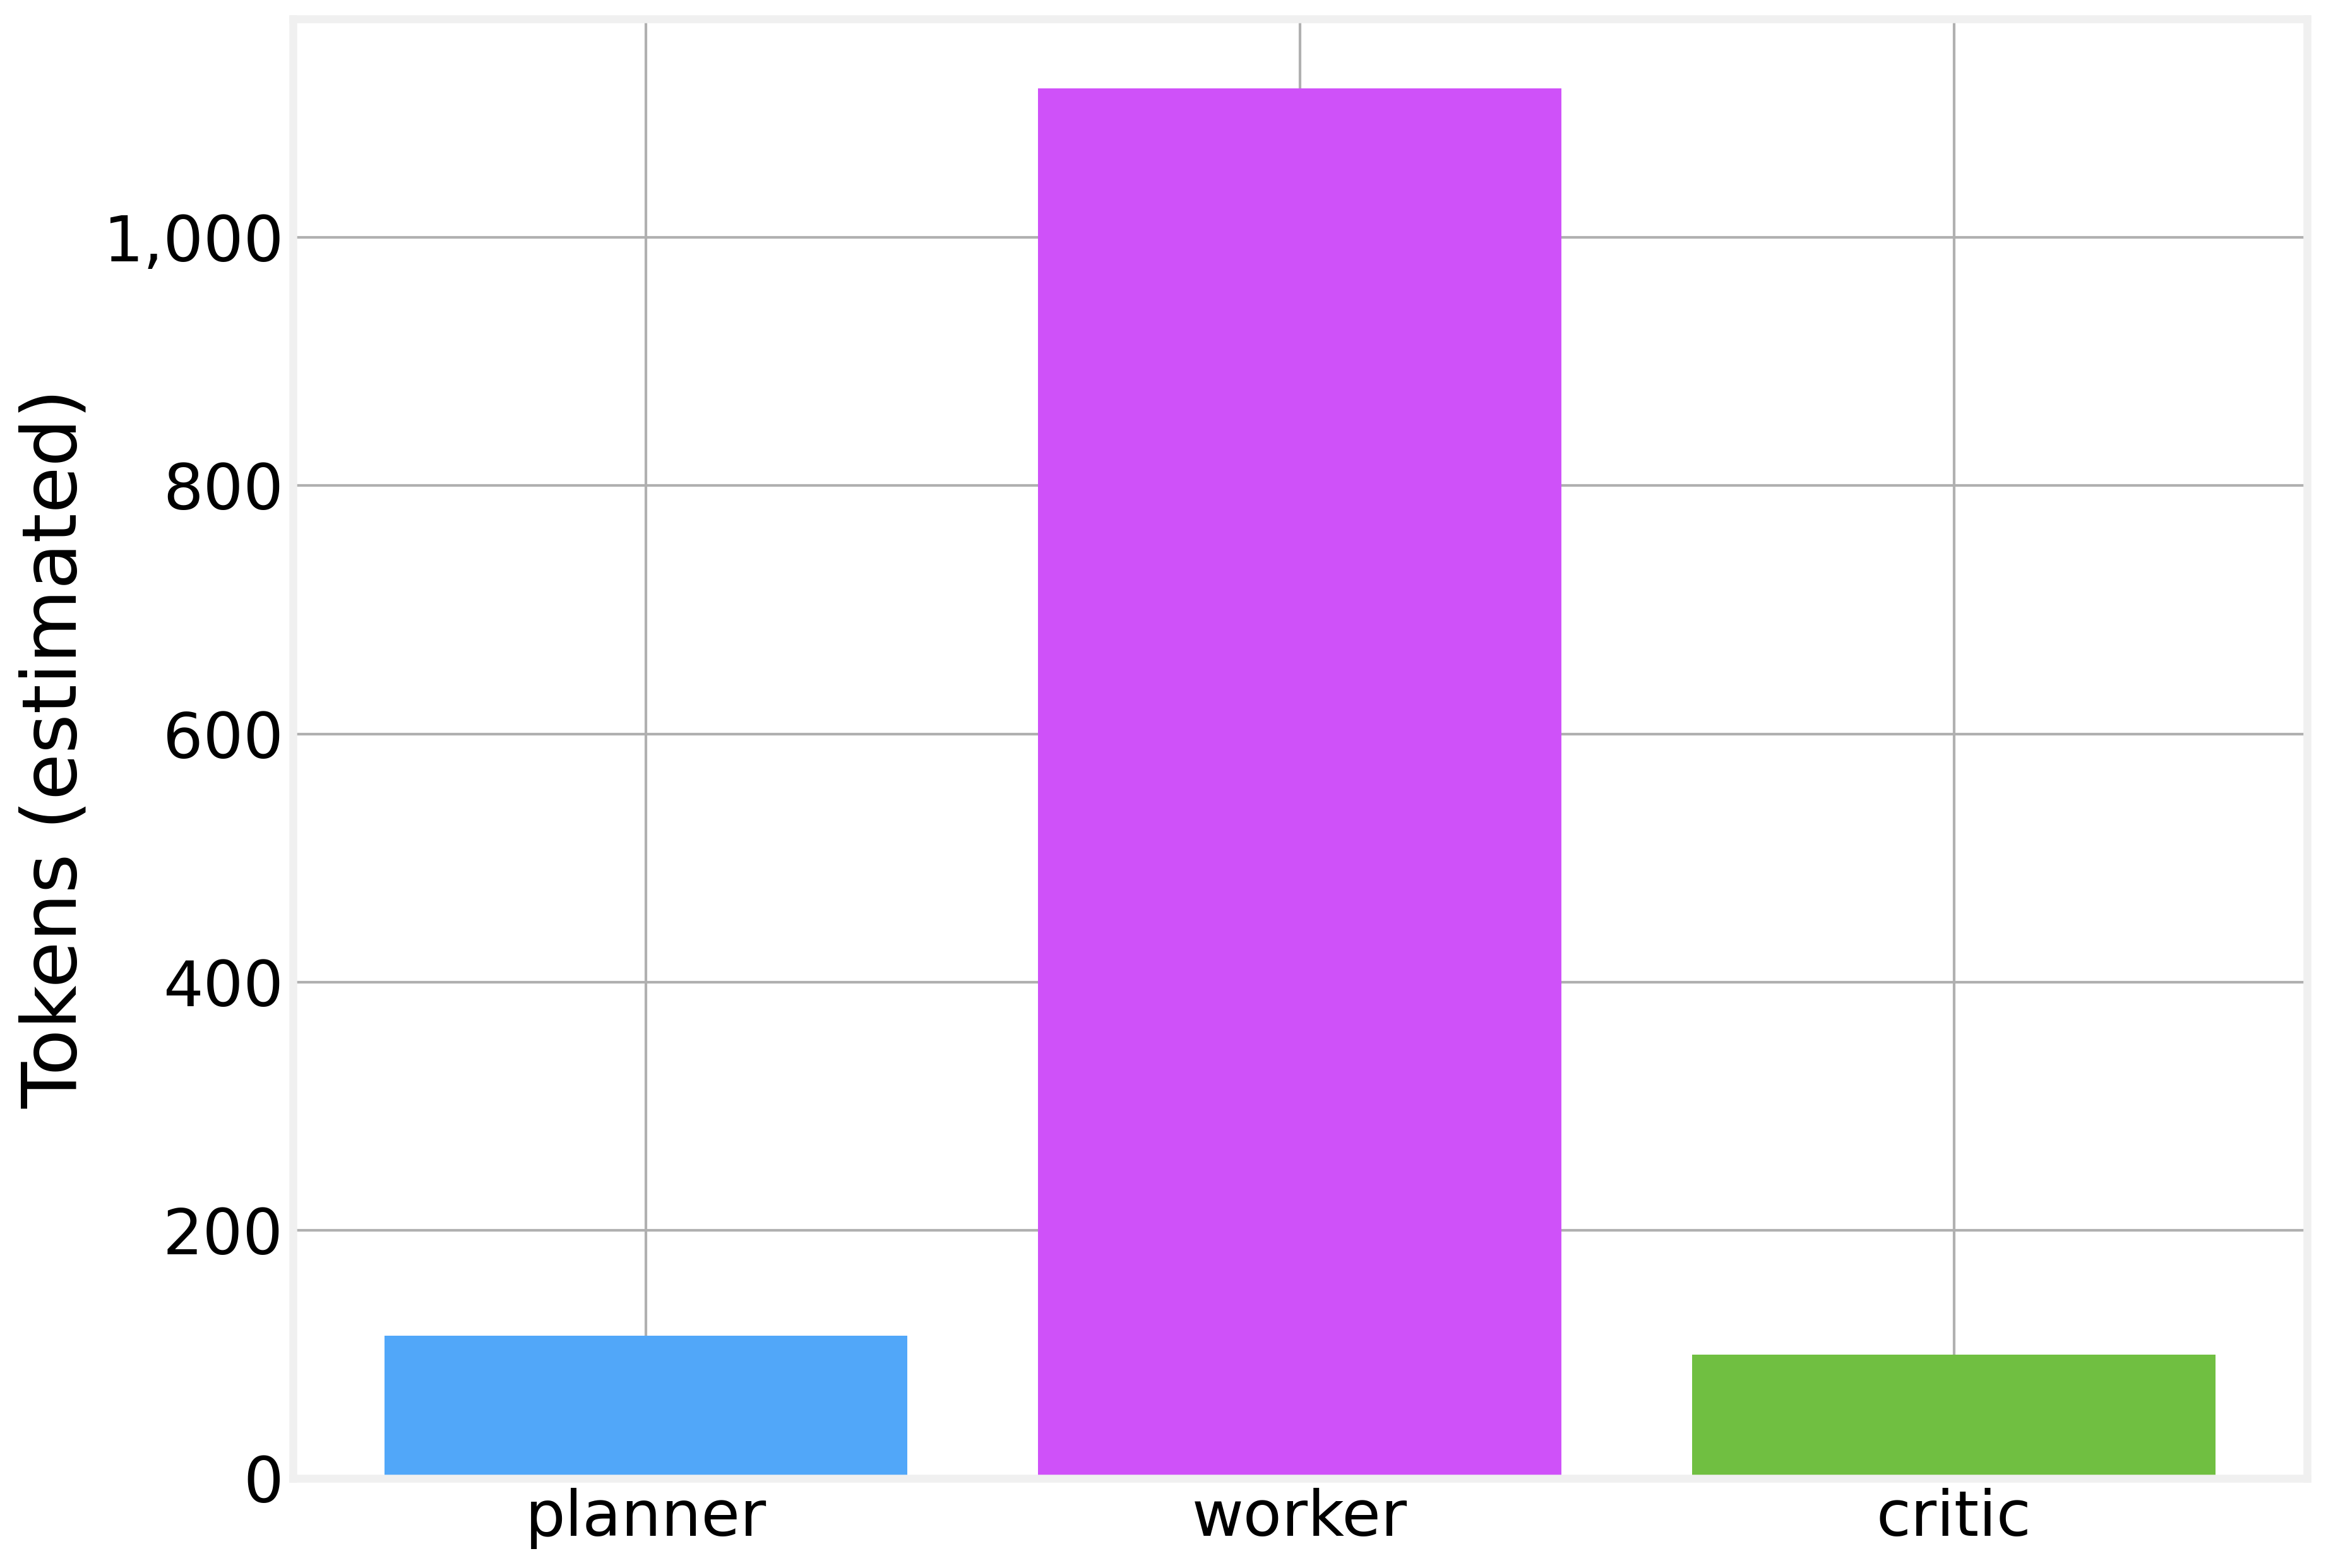

In [26]:
by_role: dict[str, int] = {}
for e in events:
    by_role[e["role"]] = by_role.get(e["role"], 0) + e["tokens"]

fig, ax = plt.subplots()
ax.bar(by_role.keys(), by_role.values(),
       color=[role_colors[r] for r in by_role])
ax.set_ylabel("Tokens (estimated)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>